# 02 - Tiempo, FFT y PSD

Acá comparo dos registros reales y fijos de DroneRF: fondo `dronerf_00000_0` y
actividad de dron `dronerf_10000_0`, siempre usando la parte L. Primero los miro en el
tiempo y después paso a FFT, periodograma y PSD por Welch.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

SRC = RAIZ / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from aps_drone_rf.config import DATA_DIR, DRONERF_TIME_FS_HZ, FIGURES_DIR, TABLES_DIR
from aps_drone_rf.estilo import COLORES, aplicar_estilo_matplotlib, color_clase
from aps_drone_rf.io import discover_signal_manifest, load_record
from aps_drone_rf.plots import save_figure
from aps_drone_rf.preprocessing import select_representative_window
from aps_drone_rf.spectral import (
    band_power,
    fft_magnitude,
    integrate_psd_power,
    periodogram_psd,
    welch_psd,
)

aplicar_estilo_matplotlib()
plt.rcParams["figure.figsize"] = (9, 4)


## Cargo el mismo par en todas las ejecuciones

No tomo “el primer archivo que aparezca”. Busco los dos `group_id` fijados y verifico
que ambos sean de la parte L. Leo 100.000 muestras de cada registro y trabajo con
amplitudes normalizadas, por lo que las comparaciones son relativas.


In [2]:
manifest = discover_signal_manifest(DATA_DIR)

if manifest.empty:
    raise FileNotFoundError(
        "No encontré DroneRF. Definí DATA_DIR antes de ejecutar este notebook."
    )

seleccion = manifest[
    (manifest["dronerf_part"].str.upper() == "L")
    & manifest["group_id"].isin(["dronerf_00000_0", "dronerf_10000_0"])
].copy()

if set(seleccion["group_id"]) != {"dronerf_00000_0", "dronerf_10000_0"}:
    raise FileNotFoundError("Faltan los grupos DroneRF fijados para la comparación")

fila_fondo = seleccion[seleccion["group_id"] == "dronerf_00000_0"].iloc[0]
fila_dron = seleccion[seleccion["group_id"] == "dronerf_10000_0"].iloc[0]

fs = DRONERF_TIME_FS_HZ
rec_fondo = load_record(fila_fondo, fs_hz=fs, normalize=True)
rec_dron = load_record(fila_dron, fs_hz=fs, normalize=True)

N = min(100_000, len(rec_fondo.signal), len(rec_dron.signal))
ts = 1 / fs
df = fs / N
tt = np.arange(N) * ts
xx_fondo = np.real(rec_fondo.signal[:N])
xx_dron = np.real(rec_dron.signal[:N])

tabla_datos = pd.DataFrame(
    [
        {"clase": "Fondo", "group_id": rec_fondo.group_id, "parte": "L", "N": N},
        {"clase": "Dron", "group_id": rec_dron.group_id, "parte": "L", "N": N},
    ]
)

print(f"fs = {fs / 1e6:.1f} MHz")
print(f"N = {N}")
print(f"df = {df:.1f} Hz")
display(tabla_datos)


fs = 40.0 MHz
N = 100000
df = 400.0 Hz


,clase,group_id,parte,N
0,Fondo,dronerf_00000_0,L,100000
1,Dron,dronerf_10000_0,L,100000


## Vista completa y zoom temporal

Para no elegir un tramo a ojo, divido las primeras 20.480 muestras en 20 ventanas de
1024 y tomo la que tiene un RMS más cercano a la mediana. La zona sombreada de la vista
general es la que aparece ampliada a la derecha. Cada vista general usa una escala
vertical robusta propia (percentiles 0,5 y 99,5): así un pico aislado no deja plana a
la señal completa. Las amplitudes entre paneles se comparan con RMS y pico, no por esta
escala gráfica.


C:\Users\msere\Repositorios\APS\src\aps_drone_rf\plots.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


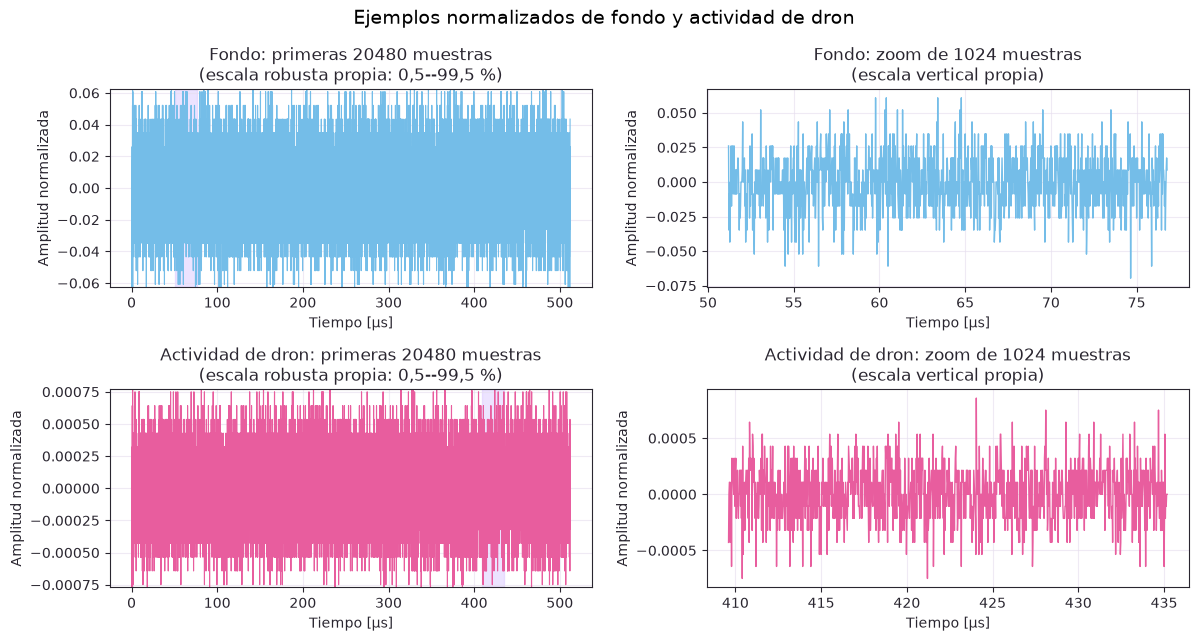

,clase,inicio_zoom,rms_zoom,pico_zoom
0,Fondo,2048,0.020979,0.069565
1,Actividad de dron,16384,0.000255,0.000857


In [3]:
n_ventana = 1024
n_vista = 20 * n_ventana
inicio_fondo, ventana_fondo = select_representative_window(
    xx_fondo[:n_vista], n_ventana, candidate_windows=20
)
inicio_dron, ventana_dron = select_representative_window(
    xx_dron[:n_vista], n_ventana, candidate_windows=20
)

fig, ejes = plt.subplots(2, 2, figsize=(12, 6.5), constrained_layout=True)
casos = [
    ("Fondo", xx_fondo, inicio_fondo, ventana_fondo, color_clase("fondo")),
    ("Actividad de dron", xx_dron, inicio_dron, ventana_dron, color_clase("dron")),
]

for fila, (nombre, senal, inicio, ventana, color) in enumerate(casos):
    tiempo_general = np.arange(n_vista) / fs * 1e6
    tiempo_zoom = np.arange(inicio, inicio + n_ventana) / fs * 1e6

    ejes[fila, 0].plot(tiempo_general, senal[:n_vista], color=color, lw=0.8)
    ejes[fila, 0].axvspan(
        inicio / fs * 1e6,
        (inicio + n_ventana) / fs * 1e6,
        color=COLORES["lila_claro"],
        alpha=0.45,
    )
    limite_inferior, limite_superior = np.quantile(senal[:n_vista], [0.005, 0.995])
    margen = 0.10 * (limite_superior - limite_inferior)
    if margen == 0:
        margen = 1e-6
    ejes[fila, 0].set_ylim(limite_inferior - margen, limite_superior + margen)
    ejes[fila, 0].set_title(
        f"{nombre}: primeras {n_vista} muestras\n"
        "(escala robusta propia: 0,5--99,5 %)"
    )
    ejes[fila, 0].set_xlabel("Tiempo [µs]")
    ejes[fila, 0].set_ylabel("Amplitud normalizada")

    ejes[fila, 1].plot(tiempo_zoom, ventana, color=color, lw=1.0)
    ejes[fila, 1].set_title(
        f"{nombre}: zoom de {n_ventana} muestras\n(escala vertical propia)"
    )
    ejes[fila, 1].set_xlabel("Tiempo [µs]")
    ejes[fila, 1].set_ylabel("Amplitud normalizada")

fig.suptitle("Ejemplos normalizados de fondo y actividad de dron", fontsize=14)
save_figure(fig, FIGURES_DIR / "nb02_tiempo_fondo_vs_dron.png")
plt.show()

tabla_tiempo = pd.DataFrame(
    [
        {
            "clase": nombre,
            "inicio_zoom": inicio,
            "rms_zoom": np.sqrt(np.mean(ventana**2)),
            "pico_zoom": np.max(np.abs(ventana)),
        }
        for nombre, _, inicio, ventana, _ in casos
    ]
)
tabla_tiempo.to_csv(TABLES_DIR / "nb02_resumen_temporal.csv", index=False)
display(tabla_tiempo)


 el fondo y el registro con dron no tienen la misma forma local, y el
zoom permite ver oscilaciones que quedaban escondidas en la vista general.

 el dominio temporal sirve para revisar amplitud, RMS y forma,
pero no alcanza para saber en qué frecuencias se reparte la energía.

 cada vista general usa una escala robusta propia, por lo que no sirve para
comparar amplitudes entre paneles. Son dos registros normalizados: la amplitud no
representa potencia física y esta figura sola no demuestra una diferencia general entre
clases.


## FFT completa y banda ampliada

Calculo la FFT con Hann. Para elegir el zoom uso las cuatro bandas fijas de 5 MHz y tomo
la que presenta la mayor diferencia de potencia relativa en la PSD de Welch. Así el
detalle se elige con una regla y no mirando previamente qué pico conviene mostrar.


C:\Users\msere\Repositorios\APS\src\aps_drone_rf\plots.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


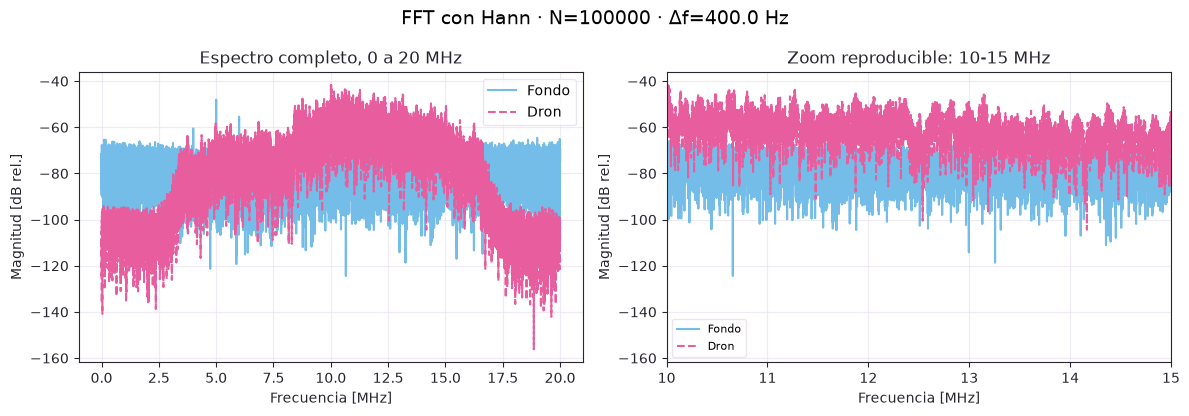

Banda con mayor diferencia relativa: 10-15 MHz


In [4]:
nperseg = 4096
noverlap = nperseg // 2
bandas_hz = [(0, 5e6), (5e6, 10e6), (10e6, 15e6), (15e6, 20e6)]

f_w_fondo, p_w_fondo = welch_psd(
    xx_fondo, fs, nperseg=nperseg, noverlap=noverlap, window="hann"
)
f_w_dron, p_w_dron = welch_psd(
    xx_dron, fs, nperseg=nperseg, noverlap=noverlap, window="hann"
)

pot_fondo = band_power(f_w_fondo, p_w_fondo, bandas_hz)
pot_dron = band_power(f_w_dron, p_w_dron, bandas_hz)
total_fondo = integrate_psd_power(f_w_fondo, p_w_fondo)
total_dron = integrate_psd_power(f_w_dron, p_w_dron)
rel_fondo = np.array(list(pot_fondo.values())) / sum(pot_fondo.values())
rel_dron = np.array(list(pot_dron.values())) / sum(pot_dron.values())
indice_zoom = int(np.argmax(np.abs(rel_fondo - rel_dron)))
f_min, f_max = bandas_hz[indice_zoom]

ff, mag_fondo, _ = fft_magnitude(
    xx_fondo, fs, window="hann", detrend=True
)
_, mag_dron, _ = fft_magnitude(xx_dron, fs, window="hann", detrend=True)
mag_fondo_db = 20 * np.log10(np.maximum(mag_fondo, 1e-15))
mag_dron_db = 20 * np.log10(np.maximum(mag_dron, 1e-15))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for eje in ejes:
    eje.plot(
        ff / 1e6,
        mag_fondo_db,
        color=color_clase("fondo"),
        ls="-",
        label="Fondo",
    )
    eje.plot(
        ff / 1e6,
        mag_dron_db,
        color=color_clase("dron"),
        ls="--",
        label="Dron",
    )
    eje.set_xlabel("Frecuencia [MHz]")
    eje.set_ylabel("Magnitud [dB rel.]")

ejes[0].set_title("Espectro completo, 0 a 20 MHz")
ejes[0].legend()
ejes[1].set_xlim(f_min / 1e6, f_max / 1e6)
ejes[1].set_title(f"Zoom reproducible: {f_min / 1e6:.0f}-{f_max / 1e6:.0f} MHz")

ejes[1].legend(fontsize=8)

fig.suptitle(f"FFT con Hann · N={N} · Δf={df:.1f} Hz", fontsize=14)
save_figure(fig, FIGURES_DIR / "nb02_fft_fondo_vs_dron.png")
plt.show()

print(
    f"Banda con mayor diferencia relativa: "
    f"{f_min / 1e6:.0f}-{f_max / 1e6:.0f} MHz"
)


 el espectro completo muestra la forma general y el panel ampliado deja
comparar los máximos dentro de la banda seleccionada sin perder el contexto.

 Hann reduce la fuga espectral respecto de la ventana rectangular y
la resolución de la grilla queda determinada por `Δf = fs/N`.

 un pico dominante no identifica por sí solo un dron. La posición y magnitud
pueden variar entre segmentos, modelos, modos y condiciones de adquisición.


## PSD por Welch completa y ampliada

Welch promedia tramos de 4096 muestras con 50 % de solapamiento. Mantengo la misma banda
de zoom elegida antes para poder relacionar la FFT con una estimación de potencia más
estable.


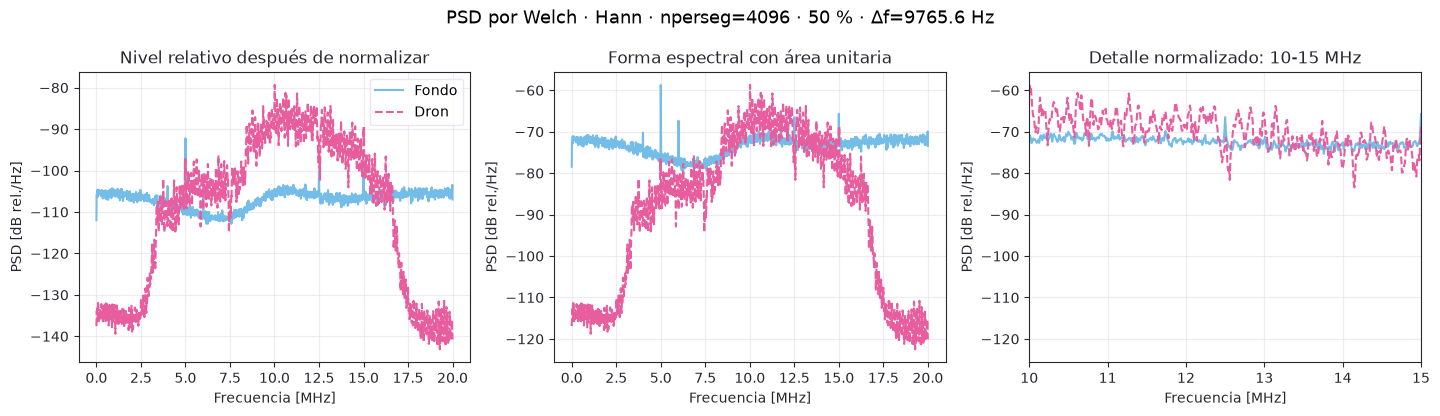

In [5]:
p_w_fondo_db = 10 * np.log10(np.maximum(p_w_fondo, 1e-30))
p_w_dron_db = 10 * np.log10(np.maximum(p_w_dron, 1e-30))
forma_fondo = p_w_fondo / integrate_psd_power(f_w_fondo, p_w_fondo)
forma_dron = p_w_dron / integrate_psd_power(f_w_dron, p_w_dron)
forma_fondo_db = 10 * np.log10(np.maximum(forma_fondo, 1e-30))
forma_dron_db = 10 * np.log10(np.maximum(forma_dron, 1e-30))
df_welch = fs / nperseg

fig, ejes = plt.subplots(1, 3, figsize=(14.5, 4.2), constrained_layout=True)
for eje, fondo, dron in [
    (ejes[0], p_w_fondo_db, p_w_dron_db),
    (ejes[1], forma_fondo_db, forma_dron_db),
    (ejes[2], forma_fondo_db, forma_dron_db),
]:
    eje.plot(
        f_w_fondo / 1e6,
        fondo,
        color=color_clase("fondo"),
        ls="-",
        label="Fondo",
    )
    eje.plot(
        f_w_dron / 1e6,
        dron,
        color=color_clase("dron"),
        ls="--",
        label="Dron",
    )
    eje.set_xlabel("Frecuencia [MHz]")
    eje.set_ylabel("PSD [dB rel./Hz]")

ejes[0].set_title("Nivel relativo después de normalizar")
ejes[0].legend()
ejes[1].set_title("Forma espectral con área unitaria")
ejes[2].set_xlim(f_min / 1e6, f_max / 1e6)
ejes[2].set_title(f"Detalle normalizado: {f_min / 1e6:.0f}-{f_max / 1e6:.0f} MHz")

fig.suptitle(
    f"PSD por Welch · Hann · nperseg={nperseg} · 50 % · Δf={df_welch:.1f} Hz",
    fontsize=13,
)
save_figure(fig, FIGURES_DIR / "nb02_welch_fondo_vs_dron.png")
plt.show()


 Welch conserva las diferencias generales de distribución espectral y
suaviza la variación fina que aparece en una FFT individual.

 al promediar segmentos baja la varianza de la estimación, a
cambio de una grilla más gruesa que la FFT hecha con las 100.000 muestras.

 la PSD está expresada en unidades relativas porque los registros fueron
normalizados y no existe una calibración de potencia del receptor.


## Periodograma frente a Welch

Uso el registro con dron para ver la diferencia entre una estimación directa y otra que
promedia varios tramos.


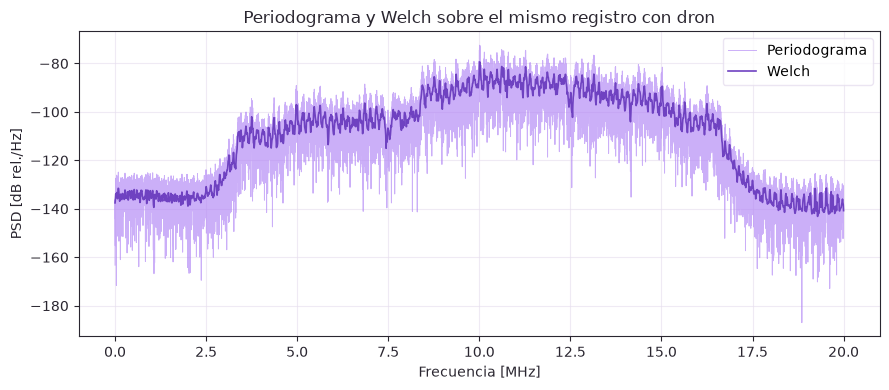

In [6]:
f_periodograma, p_periodograma = periodogram_psd(
    xx_dron, fs, window="hann", detrend="constant"
)

fig, eje = plt.subplots(figsize=(9, 4))
eje.plot(
    f_periodograma / 1e6,
    10 * np.log10(np.maximum(p_periodograma, 1e-30)),
    color=COLORES["lila"],
    lw=0.7,
    alpha=0.65,
    label="Periodograma",
)
eje.plot(
    f_w_dron / 1e6,
    p_w_dron_db,
    color=COLORES["violeta"],
    lw=1.2,
    label="Welch",
)
eje.set_title("Periodograma y Welch sobre el mismo registro con dron")
eje.set_xlabel("Frecuencia [MHz]")
eje.set_ylabel("PSD [dB rel./Hz]")
eje.legend()
save_figure(fig, FIGURES_DIR / "nb02_periodograma_vs_welch_dron.png")
plt.show()


 el periodograma tiene más oscilaciones locales, mientras que Welch deja
ver mejor la tendencia general.  es el compromiso entre varianza y
resolución trabajado en PSD.  suavizar no crea información nueva ni garantiza
que todos los picos pequeños sean ruido.


## Contenido espectral en distintos tramos

Por último divido el registro con dron en cuatro partes y repito la FFT. Esto permite ver
si la distribución frecuencial se mantiene o cambia a lo largo del archivo sin usar un
espectrograma.


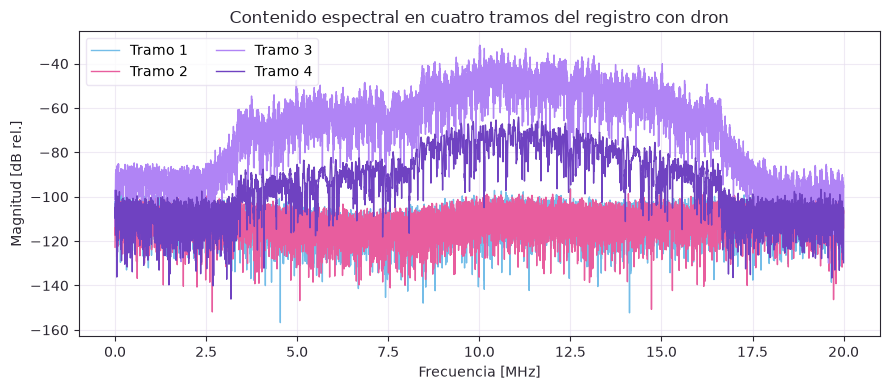

In [7]:
cantidad_tramos = 4
largo_tramo = N // cantidad_tramos

fig, eje = plt.subplots(figsize=(9, 4))
for k in range(cantidad_tramos):
    inicio = k * largo_tramo
    fin = inicio + largo_tramo
    ff_tramo, mag_tramo, _ = fft_magnitude(
        xx_dron[inicio:fin], fs, window="hann", detrend=True
    )
    eje.plot(
        ff_tramo / 1e6,
        20 * np.log10(np.maximum(mag_tramo, 1e-15)),
        label=f"Tramo {k + 1}",
        lw=1.0,
    )

eje.set_title("Contenido espectral en cuatro tramos del registro con dron")
eje.set_xlabel("Frecuencia [MHz]")
eje.set_ylabel("Magnitud [dB rel.]")
eje.legend(ncol=2)
save_figure(fig, FIGURES_DIR / "nb02_fft_tramos_temporales.png")
plt.show()


 algunos máximos cambian entre tramos, aunque la forma espectral general
conserva rasgos comunes.  un registro RF no tiene por qué ser
perfectamente estacionario.  los cuatro tramos pertenecen al mismo archivo y
no cuentan como cuatro mediciones independientes.
